### LangGraph

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages

In [2]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_API_KEY"]=os.getenv('OPENAI_API_KEY')
os.environ["GEMINI_API_KEY"]=os.getenv('GEMINI_API_KEY')
os.environ["GROQ_API_KEY"]=os.getenv('GROQ_API')
os.environ["TAVILY_API_KEY"]=os.getenv('TAVILY_API_KEY')

In [3]:
class State(TypedDict):
    messages:Annotated[list, add_messages]



In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")


In [10]:
### Node functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [11]:
graph_builder=StateGraph(State)
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge( "llmchatbot", END)

graph= graph_builder.compile()

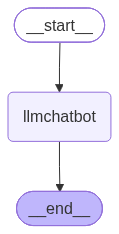

In [12]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass
    

In [24]:
response=graph.invoke({"messages":"hi"})

In [28]:
for event in graph.stream({"messages":"hi,how are you?"}):
    for value in event.values():
        print(value)

{'messages': [AIMessage(content='I am doing well, thank you for asking! I am a large language model, trained by Google. I am here to help you with any questions or tasks you may have. How can I assist you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f8298-80d5-7e23-9412-66de2bf11795-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 43, 'total_tokens': 50, 'input_token_details': {'cache_read': 0}})]}


### Chatbot with tool

In [4]:
from langchain_tavily import TavilySearch
tool =TavilySearch(max_results=2)
tool.invoke("What is langchain?")


{'query': 'What is langchain?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/langchain',
   'title': 'What is LangChain?',
   'content': 'LangChain is an open source framework for building applications based on large language models (LLMs). LLMs are large deep-learning models pre-trained on large amounts of data that can generate responses to user queries—for example, answering questions or creating images from text-based prompts. LangChain provides tools and abstractions to improve the customization, accuracy, and relevancy of the information the models generate. For example, developers can use LangChain components to build new prompt chains or customize existing templates. To do that, machine learning engineers must integrate the LLM with the organization’s internal data sources and apply *prompt engineering*—a practice where a data scientist refines inputs to a generative model with a specific structure and contex

In [6]:
def multiply(a:int , b:int)->int:
    """Multiply a abd b
    Args: 
    a(int) : first integer
    b(int) :second integer 

    return: 
       int: output int
    """
    return a*b


In [7]:
tools=[tool, multiply]

In [10]:
llm_with_tool=llm.bind_tools(tools)


In [49]:
llm_with_tool

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11', 'langchain-google-genai': '4.2.6'}}, output_version=None, profile={'name': 'Gemini 2.5 Flash-Lite', 'release_date': '2025-06-17', 'last_updated': '2025-06-17', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash-lite', client=<google.genai.client.Client object at 0x0000024D94423E00>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'

In [50]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
builder=StateGraph(State)
builder.add_edge(START, "tool_calling_llm")
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END)
graph_with_tool=builder.compile()




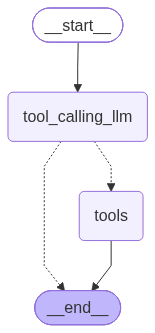

In [51]:
from IPython.display import Image, display
try:
    display(Image(graph_with_tool.get_graph().draw_mermaid_png()))
except Exception:
    pass
    

In [39]:
response=graph_with_tool.invoke({"messages":"What is latest Ai news?"})

In [40]:
for m in response["messages"]:
   m.pretty_print()

================================ Human Message =================================

What is latest Ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (95c8f6fa-ae97-41e8-b261-7be808267b15)
 Call ID: 95c8f6fa-ae97-41e8-b261-7be808267b15
  Args:
    topic: news
    query: latest AI news
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/07/18/china-ai-open-source-kimi-anthropic-openai", "title": "AI race splits in two as China wages open-weight insurgency - Axios", "score": 0.75181264, "published_date": "Sat, 18 Jul 2026 12:46:11 GMT", "content": "China's latest AI breakthrough is forcing Silicon Valley to confront a terrifying possibility: Building the world's smartest models may no longer be enough to win. **Driving th

In [ ]:
response=graph_with_tool.invoke({"messages":"What is 2 multiply by 3"})

In [53]:
for m in response["messages"]:
   m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (1c2847f6-2e33-458a-896b-2477bfaf3cea)
 Call ID: 1c2847f6-2e33-458a-896b-2477bfaf3cea
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


### ReAct Agent
- Act
- Observe
- Reasion

In [54]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
builder=StateGraph(State)
builder.add_edge(START, "tool_calling_llm")
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph_with_tool=builder.compile()




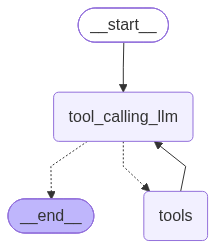

In [55]:
from IPython.display import Image, display
try:
    display(Image(graph_with_tool.get_graph().draw_mermaid_png()))
except Exception:
    pass
    

In [56]:
response=graph_with_tool.invoke({"messages":"What is 2 multiply by 3 and latest news about AI?"})

In [57]:
for m in response["messages"]:
   m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3 and latest news about AI?
================================== Ai Message ==================================
Tool Calls:
  multiply (acd47e7c-ab09-4838-9535-0ca280c61924)
 Call ID: acd47e7c-ab09-4838-9535-0ca280c61924
  Args:
    a: 2
    b: 3
  tavily_search (48fddaec-d981-43d5-8a68-605a27442254)
 Call ID: 48fddaec-d981-43d5-8a68-605a27442254
  Args:
    query: AI news
    topic: news
    time_range: day
================================= Tool Message =================================
Name: multiply

6
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reuters.com/world/us/head-us-ai-safety-agency-resigns-2026-07-20/", "title": "Head of US AI safety agency resigns - Reuters", "score": 0.56661874, "published_date": "Mon, 20

### LangGraph with memory

In [11]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
memory= MemorySaver()
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
builder=StateGraph(State)
builder.add_edge(START, "tool_calling_llm")
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph_with_tool=builder.compile(checkpointer=memory)





In [18]:
config = {
    "configurable": {
        "thread_id": "unique-session-id-123"  # Can be any string
    }
}

In [19]:
response=graph_with_tool.invoke({"messages":"Hi my name is subhan."}, config=config)
response

{'messages': [HumanMessage(content='Hi my name is subhan.', additional_kwargs={}, response_metadata={}, id='d132994e-7616-4a0f-bb64-8ac80e822b44'),
  AIMessage(content="Hi Subhan, it's nice to meet you! How can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f837c-f2ca-7830-9676-157acba111ca-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1524, 'output_tokens': 19, 'total_tokens': 1543, 'input_token_details': {'cache_read': 0}})]}

In [20]:
response=graph_with_tool.invoke({"messages":"Hi,What's my name? do you remember me?"}, config=config)
response

{'messages': [HumanMessage(content='Hi my name is subhan.', additional_kwargs={}, response_metadata={}, id='d132994e-7616-4a0f-bb64-8ac80e822b44'),
  AIMessage(content="Hi Subhan, it's nice to meet you! How can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f837c-f2ca-7830-9676-157acba111ca-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1524, 'output_tokens': 19, 'total_tokens': 1543, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content="Hi,What's my name? do you remember me?", additional_kwargs={}, response_metadata={}, id='a2bcc8f8-1121-470b-b57f-7c8d9df452a5'),
  AIMessage(content='Yes Subhan, you told me your name is Subhan. I remember you!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_g

### Streaming

In [21]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
memory= MemorySaver()

In [22]:
def superBot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [25]:
graph_builder = StateGraph(State)
graph_builder.add_edge(START, "superBot")
graph_builder.add_node("superBot", superBot)
graph_builder.add_edge("superBot", END)
graph=graph_builder.compile(checkpointer=memory)


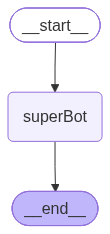

In [26]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [31]:
config = {
    "configurable": {
        "thread_id": "unique-session-id-496"  # Can be any string
    }
}

In [28]:
graph.invoke({"messages":"Hi my name is subhan. I like running."}, config=config)

{'messages': [HumanMessage(content='Hi my name is subhan. I like running.', additional_kwargs={}, response_metadata={}, id='2bb9bbce-5e83-498c-998e-4699e9b65cd8'),
  AIMessage(content="Hi Subhan! It's great to meet you. Running is a fantastic hobby. What do you enjoy most about it? Do you have any favorite routes or types of running you like to do?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f8384-7a8b-7b63-b8d5-b9883a7dcb06-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 41, 'total_tokens': 53, 'input_token_details': {'cache_read': 0}})]}

In [32]:
for event in graph.stream({"messages":"Hi my name is subhan. I like running."}, config=config, stream_mode="updates"):
    print(event)

{'superBot': {'messages': [AIMessage(content="Hi Subhan! It's great to meet you. Running is a fantastic hobby. What do you enjoy most about it? Do you have any favorite routes or distances you like to run?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f838a-5fbb-73e1-a117-c469a88298a2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 39, 'total_tokens': 51, 'input_token_details': {'cache_read': 0}})]}}


In [34]:
async for event in graph.astream_events({"messages":"I also like Cricket."}, config=config, stream_mode="values"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'I also like Cricket.'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f838c-5cf8-7101-b517-3d5f20ce41b8', 'metadata': {'thread_id': 'unique-session-id-496', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_stream', 'run_id': '019f838c-5cf8-7101-b517-3d5f20ce41b8', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': 'unique-session-id-496', 'ls_integration': 'langgraph'}, 'data': {'chunk': {'messages': [HumanMessage(content='Hi my name is subhan. I like running.', additional_kwargs={}, response_metadata={}, id='2d36031b-6ff3-4679-b308-3f7f933ae086'), AIMessage(content="Hi Subhan! It's great to meet you. Running is a fantastic hobby. What do you enjoy most about it? Do you have any favorite routes or distances you like to run?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run-

### Human in loop

In [14]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command , interrupt
from langchain_tavily import TavilySearch
from langchain.tools import tool
memory =MemorySaver()
class State(TypedDict):
    messages:Annotated[list, add_messages]
graph_builder = StateGraph(State)    

@tool 
def human_assistance(query:str)->str:
    """Request assistance  from a human."""
    human_response = interrupt({"query":query})
    return human_response["data"]

tool= TavilySearch(max_results=2)
tools=[human_assistance, tool]
llm_with_tool =llm.bind_tools(tools)
def chatbot(state:State):
    return {"messages":llm_with_tool.invoke(state["messages"])}


In [15]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools",ToolNode(tools))
graph_builder.add_conditional_edges("chatbot",tools_condition )
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("chatbot", END)
graph=graph_builder.compile(checkpointer=memory)



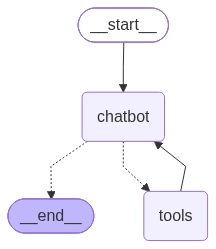

In [16]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [17]:
config = {
    "configurable": {
        "thread_id": "unique-session-id-4596"  # Can be any string
    }
}

In [26]:
for event in graph.stream({"messages":"I need some expert guidenace for building an AI agent.could you please request assistance for me?"}, config=config, stream_mode="values"):
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidenace for building an AI agent.could you please request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (7b0d7531-09db-447c-b755-cf5c9e098a4a)
 Call ID: 7b0d7531-09db-447c-b755-cf5c9e098a4a
  Args:
    query: I need some expert guidance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (7b0d7531-09db-447c-b755-cf5c9e098a4a)
 Call ID: 7b0d7531-09db-447c-b755-cf5c9e098a4a
  Args:
    query: I need some expert guidance for building an AI agent.


In [27]:
human_response =("We, expert are here to help! we recommand you to use langchain.", "it is much reliable to build agent.")
human_command= Command(resume={'data':human_response})
for event in graph.stream(human_command, config=config, stream_mode="values"):
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (7b0d7531-09db-447c-b755-cf5c9e098a4a)
 Call ID: 7b0d7531-09db-447c-b755-cf5c9e098a4a
  Args:
    query: I need some expert guidance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

["We, expert are here to help! we recommand you to use langchain.", "it is much reliable to build agent."]
================================== Ai Message ==================================
